# Lab 6 - Feature Extraction and ML with Image and Text Data

In [2]:
pip install numpy pandas matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [12]:
import os, re, time, glob, warnings
import numpy as np
import pandas as pd
import cv2
import matplotlib
if os.environ.get("MPLBACKEND") is None and not hasattr(__builtins__, "__IPYTHON__"):
    try:
        get_ipython  
    except NameError:
        matplotlib.use("Agg")         
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay)

warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)

# ---- CONFIG (edit these paths or set env vars) -------------------------------
IMAGE_DIR = os.environ.get("IMAGE_DIR", "data/asphalt")            # folder(s) with images
EMAIL_CSV = os.environ.get("EMAIL_CSV", "data/spam_ham_dataset.csv")
IMG_SIZE = (256, 256)                                              # (width, height)
os.makedirs("results", exist_ok=True)
os.makedirs("figures", exist_ok=True)

## Shared helpers

In [13]:
def evaluate(model, Xtr, ytr, Xte, yte, name, extra=None):
    """Fit, predict, time both, and return metric dict + confusion matrix."""
    t0 = time.perf_counter(); model.fit(Xtr, ytr); train_t = time.perf_counter() - t0
    t0 = time.perf_counter(); pred = model.predict(Xte); pred_t = time.perf_counter() - t0
    row = {"model": name,
           "accuracy": accuracy_score(yte, pred),
           "precision": precision_score(yte, pred, zero_division=0),
           "recall": recall_score(yte, pred, zero_division=0),
           "f1": f1_score(yte, pred, zero_division=0),
           "train_time_s": train_t, "predict_time_s": pred_t}
    if extra: row.update(extra)
    return row, confusion_matrix(yte, pred)


def plot_confusions(cms, labels, title, path):
    n = len(cms)
    fig, axes = plt.subplots(1, n, figsize=(3.6 * n, 3.4))
    axes = np.atleast_1d(axes)
    for ax, (name, cm) in zip(axes, cms.items()):
        ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=ax, colorbar=False, cmap="Blues")
        ax.set_title(name, fontsize=9)
    fig.suptitle(title); fig.tight_layout(); fig.savefig(path, dpi=120); plt.show(); plt.close(fig)

# Part A - Image features and classification
##  Loading images, inspect shape/channels, resize, grayscale

In [14]:
NEG_HINTS = ("non", "no_", "no-", "neg", "without", "intact", "normal", "healthy", "uncrack")

def infer_label(path):
    """1 = crack, 0 = non-crack, from parent folder name (fallback: file name)."""
    parent = os.path.basename(os.path.dirname(path)).lower()
    for s in (parent, os.path.basename(path).lower()):
        if any(h in s for h in NEG_HINTS): return 0
        if "crack" in s: return 1
    return None

def load_images(root):
    exts = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tif", "*.tiff")
    paths = sorted({p for e in exts for p in glob.glob(os.path.join(root, "**", e), recursive=True)
                    + glob.glob(os.path.join(root, "**", e.upper()), recursive=True)})
    recs = []
    for p in paths:
        img = cv2.imread(p, cv2.IMREAD_UNCHANGED)          # keep original channels for inspection
        if img is None: continue
        lab = infer_label(p)
        if lab is None:
            print("WARNING: could not infer label, skipping:", p); continue
        recs.append({"path": p, "label": lab, "orig_shape": img.shape,
                     "channels": 1 if img.ndim == 2 else img.shape[2]})
    return pd.DataFrame(recs)

meta = load_images(IMAGE_DIR)
assert len(meta) > 0, f"No labelled images found under {IMAGE_DIR}"
print("Images:", len(meta))
print("Folder -> label mapping (check this is right; 1 = crack):")
print(meta.assign(folder=meta.path.map(lambda p: os.path.basename(os.path.dirname(p)))).groupby(["folder", "label"]).size())
print(meta["label"].map({0: "non-crack", 1: "crack"}).value_counts())
print("\nOriginal shapes:\n", meta["orig_shape"].value_counts().head())
print("\nChannels:\n", meta["channels"].value_counts())

def to_bgr_resized(path):
    img = cv2.imread(path, cv2.IMREAD_COLOR)                # force 3 channels
    return cv2.resize(img, IMG_SIZE, interpolation=cv2.INTER_AREA)

def to_gray(bgr):
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)

Images: 400
Folder -> label mapping (check this is right; 1 = crack):
folder     label
Cracks     1        200
NonCracks  0        200
dtype: int64
label
crack        200
non-crack    200
Name: count, dtype: int64

Original shapes:
 orig_shape
(448, 448, 3)    400
Name: count, dtype: int64

Channels:
 channels
3    400
Name: count, dtype: int64


## Sample images and Canny edge visualisation

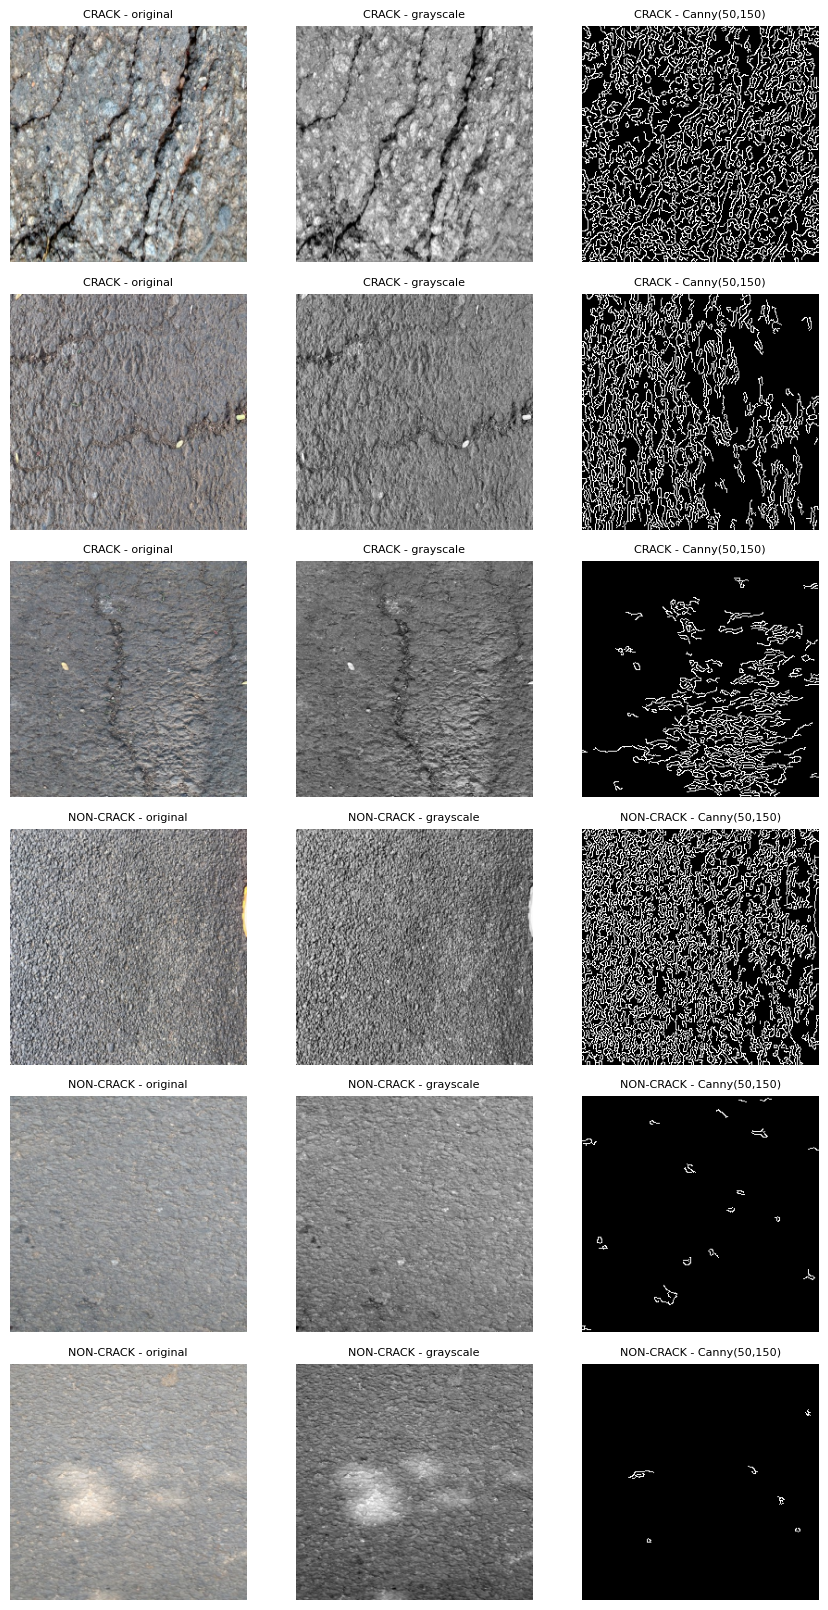

In [15]:
def show_samples(meta, n=3, path="figures/samples_and_canny.png", lo=50, hi=150):
    rows = []
    for lab in (1, 0):
        rows += list(meta[meta.label == lab].sample(min(n, (meta.label == lab).sum()), random_state=SEED).itertuples())
    fig, axes = plt.subplots(len(rows), 3, figsize=(9, 2.7 * len(rows)))
    for r, row in enumerate(rows):
        bgr = to_bgr_resized(row.path); g = to_gray(bgr)
        edges = cv2.Canny(cv2.GaussianBlur(g, (5, 5), 0), lo, hi)
        for c, (im, t, cm) in enumerate([(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB), "original", None),
                                         (g, "grayscale", "gray"), (edges, f"Canny({lo},{hi})", "gray")]):
            axes[r, c].imshow(im, cmap=cm); axes[r, c].axis("off")
            axes[r, c].set_title(f"{'CRACK' if row.label else 'NON-CRACK'} - {t}", fontsize=8)
    fig.tight_layout(); fig.savefig(path, dpi=120); plt.show(); plt.close(fig)

show_samples(meta)

## Baseline features 

In [16]:
def entropy(g):
    p = np.bincount(g.ravel(), minlength=256) / g.size
    p = p[p > 0]
    return float(-(p * np.log2(p)).sum())

def baseline_features(g, lo=50, hi=150):
    x = g.astype(np.float64)
    mu, sd = x.mean(), x.std()
    z = (x - mu) / (sd + 1e-9)
    edges = cv2.Canny(cv2.GaussianBlur(g, (5, 5), 0), lo, hi)
    n_edge = int((edges > 0).sum())
    return {
        "mean_brightness": mu, "contrast_std": sd, "median": float(np.median(x)),
        "min": x.min(), "max": x.max(), "p5": np.percentile(x, 5), "p95": np.percentile(x, 95),
        "skewness": float((z ** 3).mean()), "kurtosis": float((z ** 4).mean() - 3),
        "dark_ratio": float((g < 50).mean()), "bright_ratio": float((g > 200).mean()),
        "entropy": entropy(g),
        "edge_count": n_edge, "edge_density": n_edge / g.size,
    }

def build_table(meta, feat_fn):
    rows = []
    for r in meta.itertuples():
        g = to_gray(to_bgr_resized(r.path))
        d = feat_fn(g); d["image"] = os.path.basename(r.path); d["label"] = r.label
        rows.append(d)
    df = pd.DataFrame(rows)
    return df[["image"] + [c for c in df.columns if c not in ("image", "label")] + ["label"]]

t0 = time.perf_counter()
feat_base = build_table(meta, baseline_features)
t_extract_base = time.perf_counter() - t0
feat_base.to_csv("results/image_features_baseline.csv", index=False)
print(f"Baseline: {feat_base.shape[1]-2} features, extraction {t_extract_base:.1f}s")
feat_base.head()

Baseline: 14 features, extraction 5.2s


,image,mean_brightness,contrast_std,median,min,max,p5,p95,skewness,kurtosis,dark_ratio,bright_ratio,entropy,edge_count,edge_density,label
0,IMG_20180513_164959951_HDR resized_448.jpg,122.100815,30.727239,120.0,23.0,246.0,74.0,177.0,0.307960,-0.007342,0.002945,0.009232,6.971862,14780,0.225525,1
1,IMG_20180513_165129852_HDR resized_448.jpg,131.825958,23.529472,133.0,2.0,245.0,91.0,168.0,-0.300984,1.088593,0.002518,0.003479,6.569990,8763,0.133713,1
2,IMG_20180513_165150613_HDR resized_448.jpg,121.171707,29.188682,120.0,3.0,242.0,74.0,174.0,0.091771,0.892264,0.012360,0.006393,6.860953,10809,0.164932,1
3,IMG_20180513_165345878_HDR resized_448.jpg,130.118713,24.924452,131.0,19.0,253.0,88.0,169.0,-0.091676,0.492174,0.001450,0.003662,6.674229,12873,0.196426,1
4,IMG_20180513_165349788_HDR resized_448.jpg,131.083832,25.470919,132.0,14.0,253.0,88.0,170.0,-0.044099,0.895472,0.002106,0.005524,6.697222,11593,0.176895,1


## Train/test split and classifiers 

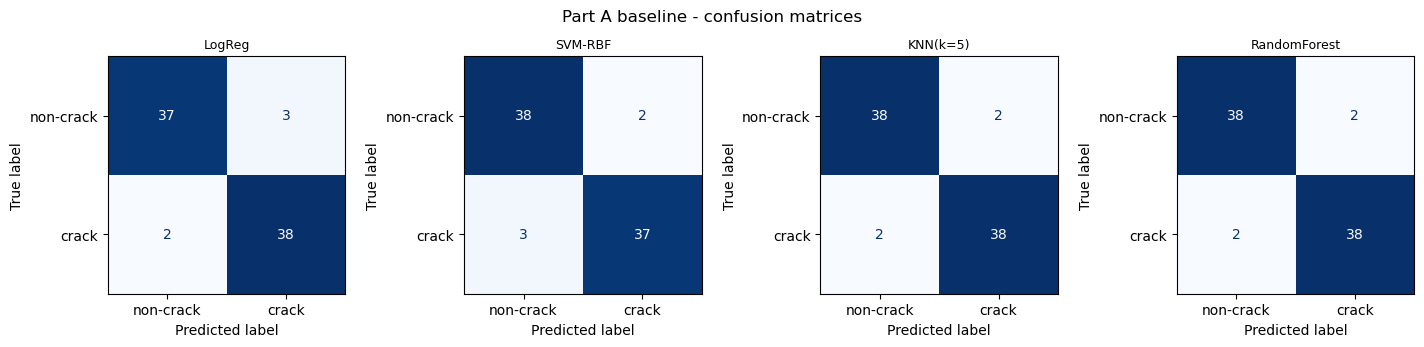

,features,model,accuracy,precision,recall,f1,train_time_s,predict_time_s,cv5_f1,n_features
0,baseline,LogReg,0.9375,0.9268,0.950,0.9383,0.0095,0.0003,0.9369,14
1,baseline,SVM-RBF,0.9375,0.9487,0.925,0.9367,0.0032,0.0009,0.9623,14
2,baseline,KNN(k=5),0.9500,0.9500,0.950,0.9500,0.0027,0.0079,0.9466,14
3,baseline,RandomForest,0.9500,0.9500,0.950,0.9500,0.5582,0.0598,0.9558,14


In [17]:
def image_models():
    return {
        "LogReg": make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, random_state=SEED)),
        "SVM-RBF": make_pipeline(StandardScaler(), SVC(kernel="rbf", C=1.0, random_state=SEED)),
        "KNN(k=5)": make_pipeline(StandardScaler(), KNeighborsClassifier(5)),
        "RandomForest": RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1),
    }

def run_image_experiment(feat_df, tag):
    X = feat_df.drop(columns=["image", "label"]).values; y = feat_df["label"].values
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
    rows, cms = [], {}
    cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
    for name, m in image_models().items():
        cvf1 = cross_val_score(m, X, y, cv=cv, scoring="f1").mean()   # extra robustness: only 400 images
        row, cm = evaluate(m, Xtr, ytr, Xte, yte, name, {"cv5_f1": cvf1, "n_features": X.shape[1]})
        rows.append(row); cms[name] = cm
    res = pd.DataFrame(rows); res.insert(0, "features", tag)
    return res, cms

res_a_base, cms_a_base = run_image_experiment(feat_base, "baseline")
res_a_base.to_csv("results/part_a_baseline_results.csv", index=False)
plot_confusions(cms_a_base, ["non-crack", "crack"], "Part A baseline - confusion matrices",
                "figures/part_a_confusion_baseline.png")
res_a_base.round(4)

# Part B - Text vectorisation and spam classification
## Load, inspect, clean

Columns: ['Email No.', 'the', 'to', 'ect', 'and'] ... | shape: (5172, 3002)
Detected pre-counted format -> reconstructing bag-of-words documents.
y
ham     3672
spam    1500
Name: count, dtype: int64
Duplicate texts: 541


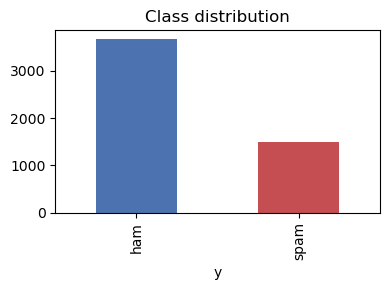


Raw   : ect a a is i i s s s as re re e e e e t t t t j m m b p c c c r r r r f h u u tu st ic far chris hr rm tr pictures pi ma picture ct ct christmas ur tm
Clean : ect a a is i i s s s as re re e e e e t t t t j m m b p c c c r r r r f h u u tu st ic far chris hr rm tr pictures pi ma picture ct ct christmas ur tm


In [18]:
emails = pd.read_csv(EMAIL_CSV)
print("Columns:", list(emails.columns[:5]), "... | shape:", emails.shape)
text_col = next((c for c in emails.columns if c.lower() in ("text", "email", "message", "body")
                 and not pd.api.types.is_numeric_dtype(emails[c])), None)   # 'email' is also a word column in the counts file
HAS_WORD_ORDER = text_col is not None      # n-grams only make sense if word order exists

if text_col is not None:                                   # raw-text CSV (label/text/label_num)
    if "label_num" in emails.columns: emails["y"] = emails["label_num"].astype(int)
    else:
        lab_col = next(c for c in emails.columns if c.lower() in ("label", "class", "category", "spam", "prediction"))
        emails["y"] = emails[lab_col].map(lambda v: 1 if str(v).lower() in ("spam", "1") else 0)
elif "Prediction" in emails.columns:
    # Kaggle "Email Spam Classification Dataset" (5,172 emails): already a 3,000-word count matrix, no raw text.
    # We rebuild a bag-of-words "pseudo-document" per email (each word repeated by its count) so that
    # CountVectorizer / TfidfVectorizer still do the vectorisation. Word ORDER is lost, hence no n-grams.
    print("Detected pre-counted format -> reconstructing bag-of-words documents.")
    words = np.array([c for c in emails.columns if c not in ("Email No.", "Prediction")])
    counts = emails[list(words)].values
    text_col = "bow_text"
    emails[text_col] = [" ".join(np.repeat(words[row > 0], row[row > 0])) for row in counts]
    emails["y"] = emails["Prediction"].astype(int)
    del counts
else:
    raise SystemExit("Unrecognised email CSV format.")
emails = emails[emails[text_col].str.len() > 0].reset_index(drop=True)
print(emails["y"].map({0: "ham", 1: "spam"}).value_counts())
print("Duplicate texts:", emails[text_col].duplicated().sum())

fig, ax = plt.subplots(figsize=(4, 3))
emails["y"].map({0: "ham", 1: "spam"}).value_counts().plot.bar(ax=ax, color=["#4c72b0", "#c44e52"])
ax.set_title("Class distribution"); fig.tight_layout(); fig.savefig("figures/spam_distribution.png", dpi=120)
plt.show(); plt.close(fig)

URL = re.compile(r"https?://\S+|www\.\S+"); TAG = re.compile(r"<[^>]+>"); NONALPHA = re.compile(r"[^a-z\s]")
def clean_text(s):
    s = str(s).lower()
    s = re.sub(r"^subject:", " ", s.strip())
    s = URL.sub(" url ", s); s = TAG.sub(" ", s)
    s = NONALPHA.sub(" ", s)
    return re.sub(r"\s+", " ", s).strip()

emails["clean"] = emails[text_col].map(clean_text)
print("\nRaw   :", emails[text_col].iloc[0][:150].replace("\n", " "))
print("Clean :", emails["clean"].iloc[0][:150])

##  CountVectorizer vs TF-IDF

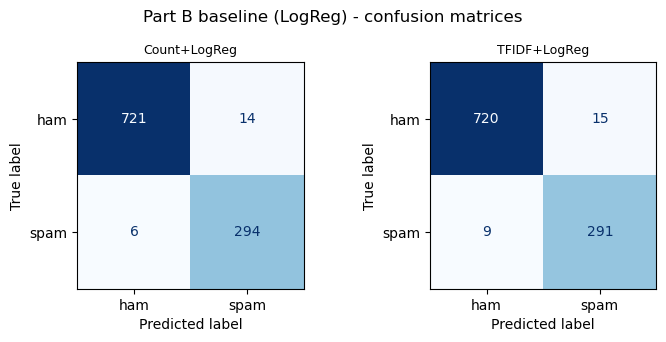

,setup,model,accuracy,precision,recall,f1,train_time_s,predict_time_s,n_features,vectorize_fit_s,vectorize_test_s,matrix_nnz,matrix_MB
0,baseline,Count+MultinomialNB,0.9420,0.8681,0.9433,0.9042,0.0070,0.0020,2974,2.2884,0.5144,605497,7.266
1,baseline,Count+LogReg,0.9807,0.9545,0.9800,0.9671,0.6669,0.0016,2974,2.2884,0.5144,605497,7.266
2,baseline,Count+LinearSVC,0.9700,0.9381,0.9600,0.9489,2.6391,0.0021,2974,2.2884,0.5144,605497,7.266
3,baseline,TFIDF+MultinomialNB,0.9459,0.8765,0.9467,0.9103,0.0094,0.0019,2974,2.3388,0.6011,605497,7.266
4,baseline,TFIDF+LogReg,0.9768,0.9510,0.9700,0.9604,0.0882,0.0010,2974,2.3388,0.6011,605497,7.266
5,baseline,TFIDF+LinearSVC,0.9845,0.9671,0.9800,0.9735,0.0886,0.0010,2974,2.3388,0.6011,605497,7.266


In [19]:
Xtr_txt, Xte_txt, ytr_txt, yte_txt = train_test_split(
    emails["clean"], emails["y"], test_size=0.2, stratify=emails["y"], random_state=SEED)

def text_models():
    return {"MultinomialNB": MultinomialNB(),
            "LogReg": LogisticRegression(max_iter=2000, random_state=SEED),
            "LinearSVC": LinearSVC(random_state=SEED)}

def run_text_experiment(vec_factory, tag):
    rows, cms = [], {}
    for vname in ("Count", "TFIDF"):
        vec = vec_factory(vname)
        t0 = time.perf_counter(); Xtr = vec.fit_transform(Xtr_txt); vec_t = time.perf_counter() - t0
        t0 = time.perf_counter(); Xte = vec.transform(Xte_txt); vec_pred_t = time.perf_counter() - t0
        for mname, m in text_models().items():
            row, cm = evaluate(m, Xtr, ytr_txt, Xte, yte_txt, f"{vname}+{mname}",
                               {"n_features": Xtr.shape[1], "vectorize_fit_s": vec_t,
                                "vectorize_test_s": vec_pred_t,
                                "matrix_nnz": Xtr.nnz, "matrix_MB": (Xtr.data.nbytes + Xtr.indices.nbytes) / 1e6})
            rows.append(row); cms[f"{vname}+{mname}"] = cm
    res = pd.DataFrame(rows); res.insert(0, "setup", tag)
    return res, cms

base_factory = lambda v: (CountVectorizer() if v == "Count" else TfidfVectorizer())
res_b_base, cms_b_base = run_text_experiment(base_factory, "baseline")
res_b_base.to_csv("results/part_b_baseline_results.csv", index=False)
plot_confusions({k: v for k, v in cms_b_base.items() if k.endswith("LogReg")}, ["ham", "spam"],
                "Part B baseline (LogReg) - confusion matrices", "figures/part_b_confusion_baseline.png")
res_b_base.round(4)

# Part C - Improve the representation
## Images: richer, multi-scale features
 the baseline uses global intensity statistics + one Canny setting, which is sensitive to
lighting and to a hand-picked threshold. Improvements: (1) Otsu-derived adaptive Canny thresholds plus
a low/high pair, (2) gradient-magnitude statistics (Sobel), (3) local-contrast via a blackhat morphological
filter (cracks are thin dark lines), (4) a coarse 4x4 grid of edge density to keep *spatial* information,
(5) lighting-normalised statistics through CLAHE.

Improved: 41 features, extraction 8.8s (baseline 5.2s)


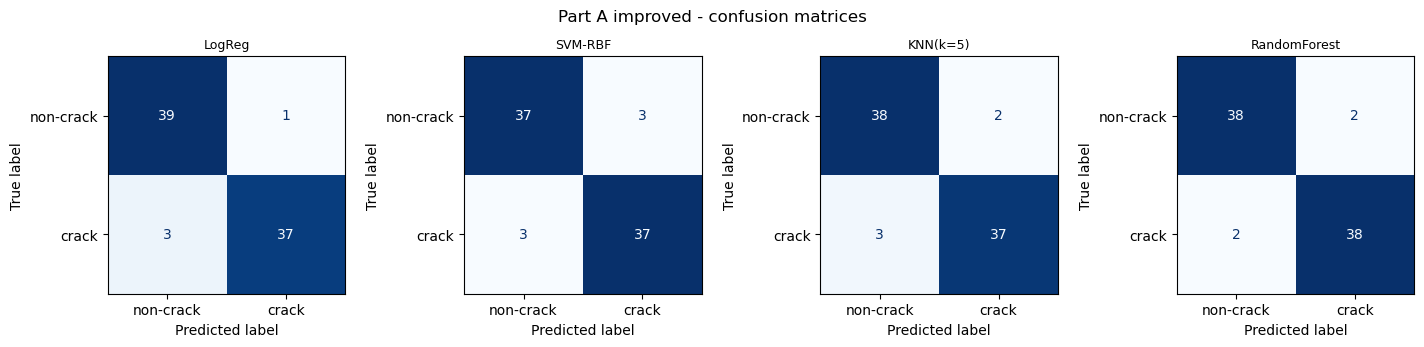

,features,model,accuracy,precision,recall,f1,train_time_s,predict_time_s,cv5_f1,n_features,extract_time_s
0,baseline,LogReg,0.9375,0.9268,0.950,0.9383,0.0095,0.0003,0.9369,14,5.1818
1,baseline,SVM-RBF,0.9375,0.9487,0.925,0.9367,0.0032,0.0009,0.9623,14,5.1818
2,baseline,KNN(k=5),0.9500,0.9500,0.950,0.9500,0.0027,0.0079,0.9466,14,5.1818
3,baseline,RandomForest,0.9500,0.9500,0.950,0.9500,0.5582,0.0598,0.9558,14,5.1818
0,improved,LogReg,0.9500,0.9737,0.925,0.9487,0.0326,0.0011,0.9526,41,8.7732
1,improved,SVM-RBF,0.9250,0.9250,0.925,0.9250,0.0063,0.0013,0.9599,41,8.7732
2,improved,KNN(k=5),0.9375,0.9487,0.925,0.9367,0.0017,0.0074,0.9542,41,8.7732
3,improved,RandomForest,0.9500,0.9500,0.950,0.9500,0.6070,0.0507,0.9578,41,8.7732


In [20]:
_clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

def improved_features(g):
    d = baseline_features(g)
    gb = cv2.GaussianBlur(g, (5, 5), 0)
    otsu, _ = cv2.threshold(gb, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    for tag, (lo, hi) in {"lo": (30, 90), "hi": (100, 200), "otsu": (0.5 * otsu, otsu)}.items():
        e = cv2.Canny(gb, lo, hi); d[f"edge_density_{tag}"] = float((e > 0).mean())
    gx, gy = cv2.Sobel(gb, cv2.CV_64F, 1, 0), cv2.Sobel(gb, cv2.CV_64F, 0, 1)
    mag = np.hypot(gx, gy)
    d.update(grad_mean=mag.mean(), grad_std=mag.std(), grad_p95=np.percentile(mag, 95))
    bh = cv2.morphologyEx(gb, cv2.MORPH_BLACKHAT, cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15)))
    d.update(blackhat_mean=float(bh.mean()), blackhat_p95=float(np.percentile(bh, 95)),
             blackhat_ratio=float((bh > 20).mean()))
    gc = _clahe.apply(g)
    d.update(clahe_std=float(gc.std()), clahe_dark_ratio=float((gc < 60).mean()))
    e = cv2.Canny(gb, 50, 150) > 0; H, W = e.shape
    for i in range(4):
        for j in range(4):
            d[f"edge_grid_{i}{j}"] = float(e[i*H//4:(i+1)*H//4, j*W//4:(j+1)*W//4].mean())
    return d

t0 = time.perf_counter()
feat_imp = build_table(meta, improved_features)
t_extract_imp = time.perf_counter() - t0
feat_imp.to_csv("results/image_features_improved.csv", index=False)
print(f"Improved: {feat_imp.shape[1]-2} features, extraction {t_extract_imp:.1f}s "
      f"(baseline {t_extract_base:.1f}s)")

res_a_imp, cms_a_imp = run_image_experiment(feat_imp, "improved")
res_a_imp["extract_time_s"] = t_extract_imp; res_a_base["extract_time_s"] = t_extract_base
plot_confusions(cms_a_imp, ["non-crack", "crack"], "Part A improved - confusion matrices",
                "figures/part_a_confusion_improved.png")
comp_a = pd.concat([res_a_base, res_a_imp]); comp_a.to_csv("results/part_c_image_comparison.csv", index=False)
comp_a.round(4)

## Text: stop-words, min_df, limited vocabulary, bigrams
 the full vocabulary contains many rare tokens (typos, names, numbers) that add
dimensions but little signal. We (1) remove English stop-words, (2) require `min_df=3`,
(3) cap the vocabulary (2000 / 1000 words for the pre-counted 3000-word dataset), and (4) test adding bigrams (which increases
dimensionality, so it is capped as well).

In [21]:
def imp_factory(ngram, maxf):
    def f(v):
        kw = dict(stop_words="english", min_df=3, max_features=maxf, ngram_range=ngram)
        return CountVectorizer(**kw) if v == "Count" else TfidfVectorizer(sublinear_tf=True, **kw)
    return f

variants = {"stop+min_df3+2000": ((1, 1), 2000), "stop+min_df3+1000": ((1, 1), 1000)}
if HAS_WORD_ORDER:   # bigrams are meaningless when word order was lost
    variants["stop+min_df3+bigram+10000"] = ((1, 2), 10000)
all_b = [res_b_base]
for tag, (ng, mf) in variants.items():
    r, _ = run_text_experiment(imp_factory(ng, mf), tag); all_b.append(r)
comp_b = pd.concat(all_b, ignore_index=True)
comp_b.to_csv("results/part_c_text_comparison.csv", index=False)
comp_b.round(4)

,setup,model,accuracy,precision,recall,f1,train_time_s,predict_time_s,n_features,vectorize_fit_s,vectorize_test_s,matrix_nnz,matrix_MB
0,baseline,Count+MultinomialNB,0.9420,0.8681,0.9433,0.9042,0.0070,0.0020,2974,2.2884,0.5144,605497,7.2660
1,baseline,Count+LogReg,0.9807,0.9545,0.9800,0.9671,0.6669,0.0016,2974,2.2884,0.5144,605497,7.2660
2,baseline,Count+LinearSVC,0.9700,0.9381,0.9600,0.9489,2.6391,0.0021,2974,2.2884,0.5144,605497,7.2660
3,baseline,TFIDF+MultinomialNB,0.9459,0.8765,0.9467,0.9103,0.0094,0.0019,2974,2.3388,0.6011,605497,7.2660
4,baseline,TFIDF+LogReg,0.9768,0.9510,0.9700,0.9604,0.0882,0.0010,2974,2.3388,0.6011,605497,7.2660
5,baseline,TFIDF+LinearSVC,0.9845,0.9671,0.9800,0.9735,0.0886,0.0010,2974,2.3388,0.6011,605497,7.2660
6,stop+min_df3+2000,Count+MultinomialNB,0.9382,0.8598,0.9400,0.8981,0.0044,0.0010,2000,1.9101,0.4956,423592,5.0831
7,stop+min_df3+2000,Count+LogReg,0.9720,0.9385,0.9667,0.9524,0.3299,0.0008,2000,1.9101,0.4956,423592,5.0831
8,stop+min_df3+2000,Count+LinearSVC,0.9662,0.9206,0.9667,0.9431,1.9356,0.0006,2000,1.9101,0.4956,423592,5.0831
9,stop+min_df3+2000,TFIDF+MultinomialNB,0.9391,0.8475,0.9633,0.9017,0.0053,0.0016,2000,2.0654,0.5579,423592,5.0831


## Trade-off plots

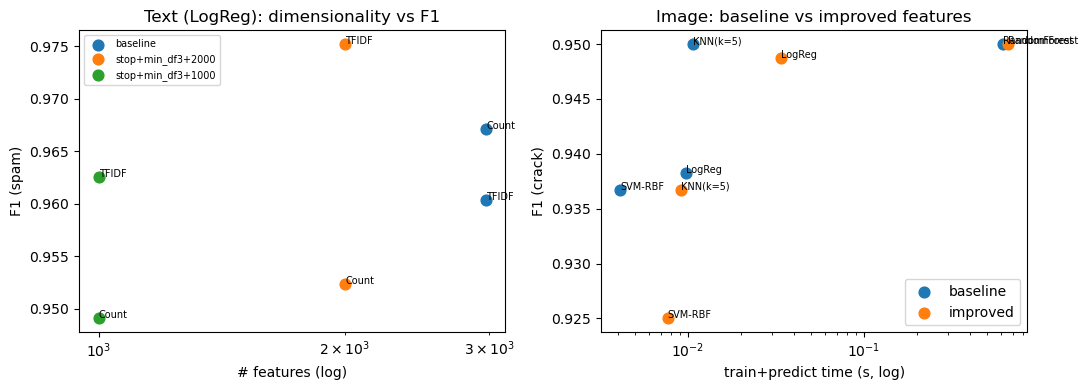


=== SUMMARY ===
          accuracy    f1  cv5_f1
features                        
baseline      0.95  0.95  0.9623
improved      0.95  0.95  0.9599
                   accuracy      f1  n_features
setup                                          
baseline             0.9845  0.9735        2974
stop+min_df3+1000    0.9807  0.9668        1000
stop+min_df3+2000    0.9855  0.9752        2000


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sub = comp_b[comp_b.model.str.endswith("LogReg")]
for setup, g in sub.groupby("setup", sort=False):
    axes[0].scatter(g.n_features, g.f1, s=60, label=setup)
    for r in g.itertuples(): axes[0].annotate(r.model.split("+")[0], (r.n_features, r.f1), fontsize=7)
axes[0].set_xscale("log"); axes[0].set_xlabel("# features (log)"); axes[0].set_ylabel("F1 (spam)")
axes[0].set_title("Text (LogReg): dimensionality vs F1"); axes[0].legend(fontsize=7)
sub2 = comp_a
for feats, g in sub2.groupby("features", sort=False):
    axes[1].scatter(g.train_time_s + g.predict_time_s, g.f1, s=60, label=feats)
    for r in g.itertuples(): axes[1].annotate(r.model, (r.train_time_s + r.predict_time_s, r.f1), fontsize=7)
axes[1].set_xscale("log"); axes[1].set_xlabel("train+predict time (s, log)"); axes[1].set_ylabel("F1 (crack)")
axes[1].set_title("Image: baseline vs improved features"); axes[1].legend()
fig.tight_layout(); fig.savefig("figures/tradeoffs.png", dpi=120); plt.show(); plt.close(fig)

print("\n=== SUMMARY ===")
print(comp_a.groupby("features")[["accuracy", "f1", "cv5_f1"]].max().round(4))
print(comp_b.groupby("setup")[["accuracy", "f1", "n_features"]].agg({"accuracy": "max", "f1": "max", "n_features": "first"}).round(4))